In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'D:\8th Semester\Machine Learning Lab\archive_2\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'D:\8th Semester\Machine Learning Lab\Computer vision\train'
validation_dir = r'D:\8th Semester\Machine Learning Lab\Computer vision\validation'
test_dir = r'D:\8th Semester\Machine Learning Lab\Computer vision\test'

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

In [32]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 127, 127, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_17 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_16 (MaxPooli  (None, 62, 62, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_18 (Conv2D)          (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_17 (MaxPooli  (None, 30, 30, 128)      

In [33]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(lr=1e-4), metrics=['acc'])

In [26]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [27]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [10]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [11]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 4,
                         callbacks = callbacks)

Epoch 1/4



50/50 [==============================] - ETA: 0s - loss: 1.3196 - acc: 0.4588
Epoch 1: val_loss improved from inf to 0.80018, saving model to D:\8th Semester\Machine Learning Lab\archive_2\E1-cp-0001-loss0.80.h5


c:\Users\Shafiq\.conda\envs\DSP\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


50/50 [==============================] - 130s 3s/step - loss: 1.3196 - acc: 0.4588 - val_loss: 0.8002 - val_acc: 0.7054
Epoch 2/4
50/50 [==============================] - ETA: 0s - loss: 0.6420 - acc: 0.7094
Epoch 2: val_loss improved from 0.80018 to 0.41529, saving model to D:\8th Semester\Machine Learning Lab\archive_2\E1-cp-0002-loss0.42.h5
50/50 [==============================] - 111s 2s/step - loss: 0.6420 - acc: 0.7094 - val_loss: 0.4153 - val_acc: 0.7991
Epoch 3/4
50/50 [==============================] - ETA: 0s - loss: 0.4664 - acc: 0.8087
Epoch 3: val_loss improved from 0.41529 to 0.38921, saving model to D:\8th Semester\Machine Learning Lab\archive_2\E1-cp-0003-loss0.39.h5
50/50 [==============================] - 109s 2s/step - loss: 0.4664 - acc: 0.8087 - val_loss: 0.3892 - val_acc: 0.8080
Epoch 4/4
50/50 [==============================] - ETA: 0s - loss: 0.4374 - acc: 0.8188
Epoch 4: val_loss improved from 0.38921 to 0.31870, saving model to D:\8th Semester\Machine Learning

In [12]:
model_history.history

{'loss': [1.0878664255142212,
  0.71486496925354,
  0.45733320713043213,
  0.3897075355052948],
 'acc': [0.5043749809265137,
  0.6743749976158142,
  0.8081250190734863,
  0.8418750166893005],
 'val_loss': [0.8814453482627869,
  0.4454910159111023,
  1.0351800918579102,
  0.4166710674762726],
 'val_acc': [0.5, 0.7991071343421936, 0.6160714030265808, 0.8035714030265808]}

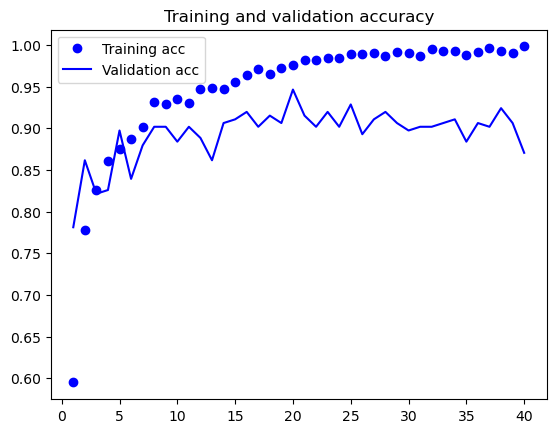

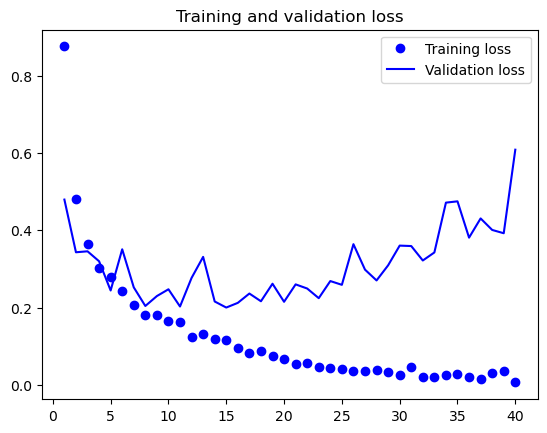

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'D:\8th Semester\Machine Learning Lab\New folder.png')

Found 200 images belonging to 4 classes.
7/7 [==============================] - 2s 242ms/step


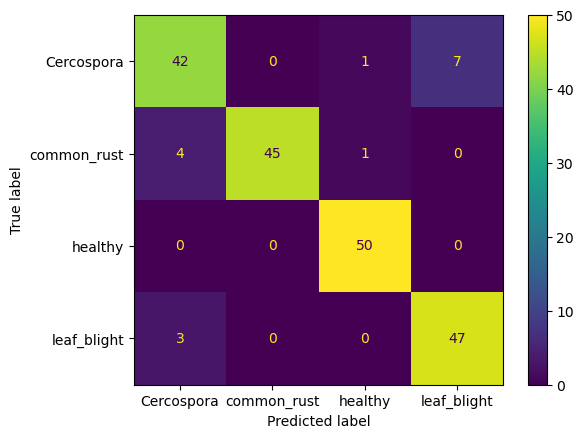

In [ ]:
model = load_model(r'D:\8th Semester\Machine Learning Lab\archive_2\E1-cp-0001-loss0.88.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
plt.savefig(r'D:\8th Semester\Machine Learning Lab\New folder.jpg')

In [ ]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.86      0.84      0.85        50
 common_rust       1.00      0.90      0.95        50
     healthy       0.96      1.00      0.98        50
 leaf_blight       0.87      0.94      0.90        50

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200

